# Uso de Redes Neurais Convolucionais (*Convolutional Neural Networks - CNN*)

**Disciplina**: Redes Neurais e Deep Learning

Especialização em Ciência de Dados - Universidade Tecnologica Federal do Paraná

Aula 04: CNNs

**Exemplo 01**: Comparando modelos densos e CNNs no problema MNIST

Linguagem de programação usada no notebook: **Python**

---


In [ ]:
# Importação das bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

In [ ]:
# Semente para reprodutibilidade dos experimentos
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:

# Carregando o dataset MNIST via Keras (ele já vem incluso)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Verificando as dimensões dos conjuntos de dados
print("* Dimensões do conjunto de treinamento:", x_train.shape)
print("* Dimensões dos rótulos de treinamento:", y_train.shape)
print("* Dimensões do conjunto de teste:", x_test.shape)
print("* Dimensões dos rótulos de teste:", y_test.shape)


* Dimensões do conjunto de treinamento: (60000, 28, 28)
* Dimensões dos rótulos de treinamento: (60000,)
* Dimensões do conjunto de teste: (10000, 28, 28)
* Dimensões dos rótulos de teste: (10000,)


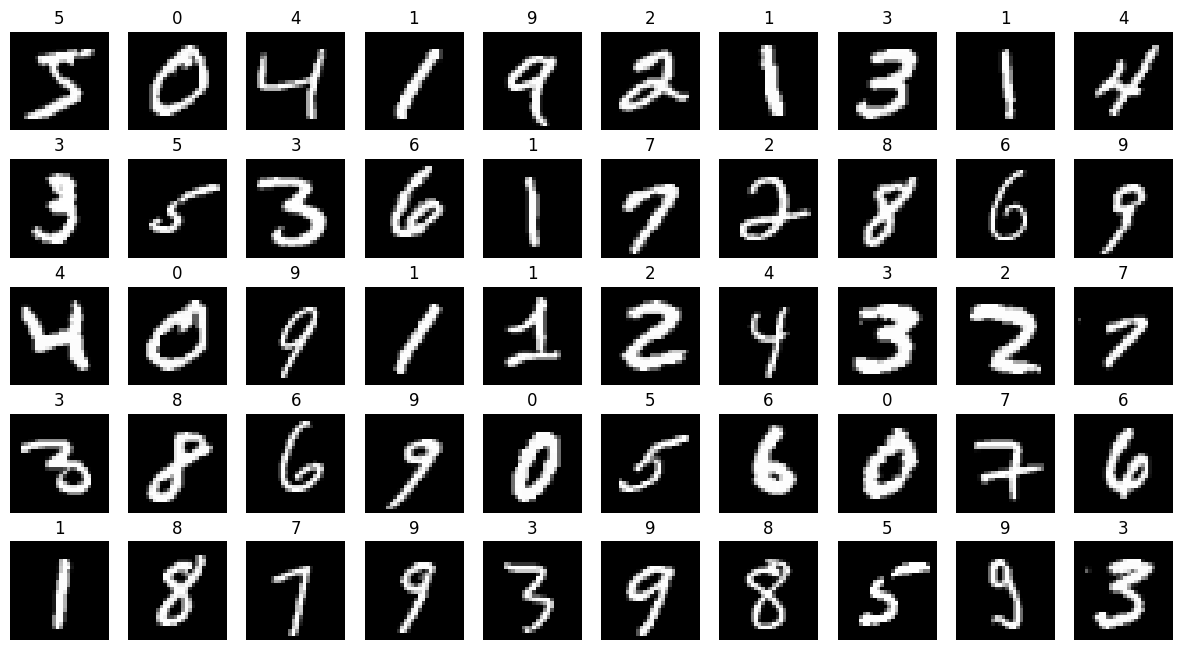

In [ ]:
# Visualizando alguns exemplos do conjunto de treinamento
plt.figure(figsize=(15, 8))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

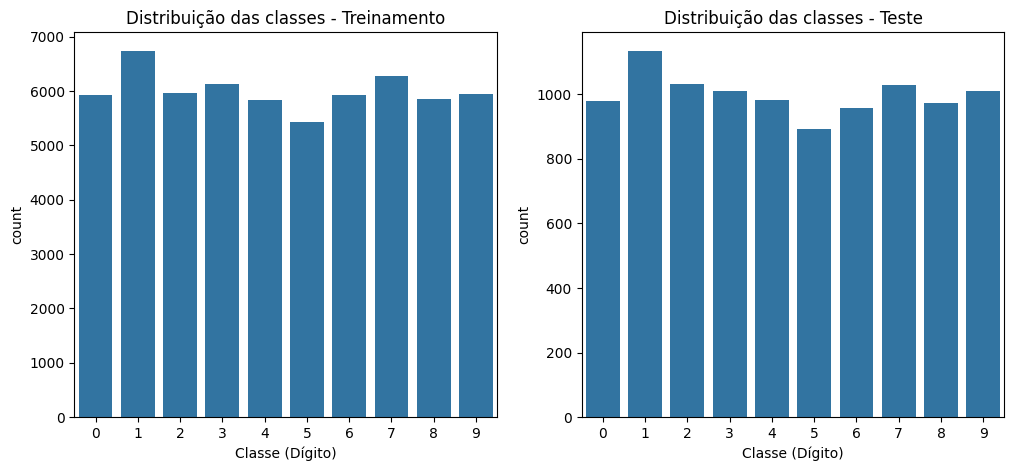

In [ ]:
# Gráfico com a distribuição das classes
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Distribuição das classes - Treinamento")
plt.xlabel("Classe (Dígito)")

plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title("Distribuição das classes - Teste")
plt.xlabel("Classe (Dígito)")
plt.show()

In [ ]:
# Pré-processamento dos dados
# Normalizando os pixels (0-255 → 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Redimensionando para incluir o canal (necessário para CNN)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [ ]:
# Convertendo os rótulos para one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# Construção do modelo de rede neural convolucional (CNN)
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Resumo da arquitetura da rede
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilação do modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Treinamento do modelo
history = model.fit(
    x_train, y_train,
    batch_size=512,
    epochs=10,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.7466 - loss: 0.8052 - val_accuracy: 0.9780 - val_loss: 0.0791
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9575 - loss: 0.1361 - val_accuracy: 0.9862 - val_loss: 0.0512
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9726 - loss: 0.0893 - val_accuracy: 0.9878 - val_loss: 0.0478
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9779 - loss: 0.0707 - val_accuracy: 0.9882 - val_loss: 0.0456
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9817 - loss: 0.0599 - val_accuracy: 0.9888 - val_loss: 0.0448
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9839 - loss: 0.0521 - val_accuracy: 0.9907 - val_loss: 0.0408
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9863 - loss: 0.0442 - val_accuracy: 0.9910 - val_loss: 0.0374
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9875 - loss: 0.0398 - val_accu

In [ ]:
# Avaliação do modelo
score = model.evaluate(x_test, y_test, verbose=0)
print(f"Acurácia no conjunto de teste: {score[1]*100:.2f}%")

In [ ]:
# Gráficos de evolução do treinamento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Função de perda durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [ ]:
# Previsões de exemplo
predictions = model.predict(x_test[:9])
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:9], axis=1)

plt.figure(figsize=(10, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {pred_classes[i]} / Real: {true_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
